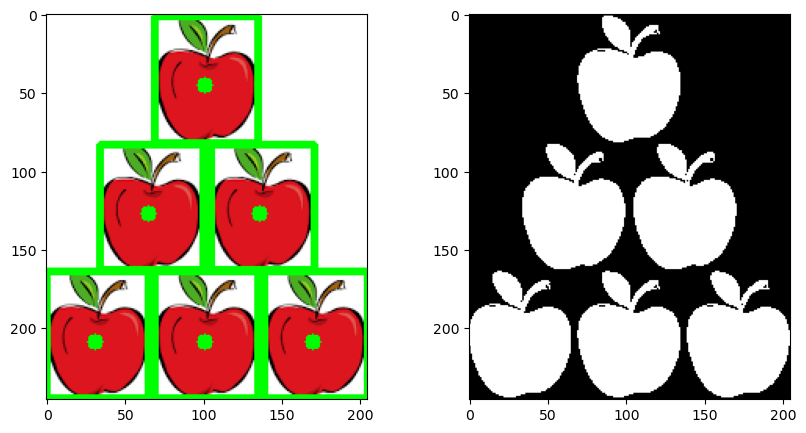

Contorno 1: Perímetro = 6.75 cm, Área = 1.38 cm²
Contorno 2: Perímetro = 6.76 cm, Área = 1.37 cm²
Contorno 3: Perímetro = 6.76 cm, Área = 1.37 cm²
Contorno 4: Perímetro = 6.74 cm, Área = 1.38 cm²
Contorno 5: Perímetro = 6.82 cm, Área = 1.37 cm²
Contorno 6: Perímetro = 6.73 cm, Área = 1.38 cm²


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('manzanas.jpeg')
pixel = 50
gray = cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)
ret,bin = cv2.threshold(gray,200, 255, cv2.THRESH_BINARY_INV)
contorno, jerarquia = cv2.findContours(bin, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
perminetros = []
areas = []
for i in range (len(contorno)):
    cnt = contorno[i]
    M = cv2.moments(cnt)
    if M ['m00']!=0:
        cx = int(M['m10']/M['m00'])
        cy = int(M['m01']/M['m00'])
    else:
        cx,cy = 0,0
    area = cv2.contourArea(cnt)
    perimetro = cv2.arcLength(cnt,True)
    perminetros.append(perimetro)
    areas.append(area)
    cv2.circle(imagen,(cx,cy),5,(0,255,0),-1)
    x,y,w,h = cv2.boundingRect(cnt)
    cv2.rectangle(imagen,(x,y),(x+w,y+h),(0,255,0),3)

plt.figure(figsize=(10,5))
plt.subplot(121)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.subplot(122)
plt.imshow(bin,cmap='gray')
plt.show()
for i, (perimetro,area) in enumerate(zip(perminetros,areas)):
    perimetro_cm = perimetro / pixel
    area_cm2 = area / (pixel** 2)
    print(f'Contorno {i+1}: Perímetro = {perimetro_cm:.2f} cm, Área = {area_cm2:.2f} cm²')

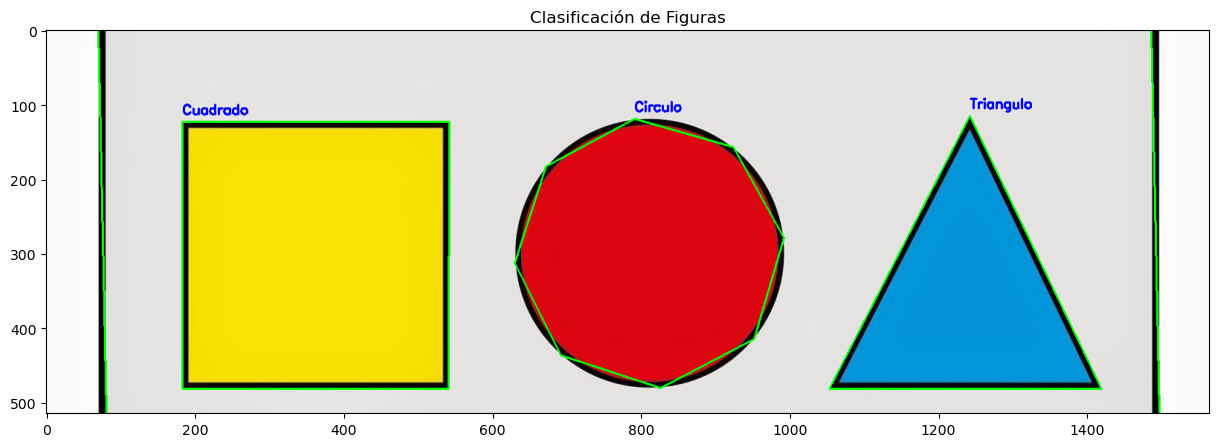

Contorno 1: Perímetro = 6.75 cm, Área = 0.02 cm²
Contorno 2: Perímetro = 6.76 cm, Área = 0.02 cm²
Contorno 3: Perímetro = 6.76 cm, Área = 0.01 cm²
Contorno 4: Perímetro = 6.74 cm, Área = 0.00 cm²
Contorno 5: Perímetro = 6.82 cm, Área = 0.00 cm²


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('figuritas2.jpg')
pixel = 50
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
_, thresh = cv2.threshold(blur, 200, 255, cv2.THRESH_BINARY_INV)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    epsilon = 0.02 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    moments = cv2.moments(cnt)
    huMoments = cv2.HuMoments(moments)
    shape = "Indefinido"
    vertices = len(approx)
    if vertices == 3:
        shape = "Triangulo"
    elif vertices == 4:
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w)/h
        shape = "Cuadrado" if 0.95 <= aspect_ratio <= 1.05 else "Rectangulo"
    elif vertices > 5:
        shape = "Circulo"
    cv2.drawContours(img, [approx], -1, (0, 255, 0), 2)
    x, y = approx.ravel()[0], approx.ravel()[1]
    cv2.putText(img, shape, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15, 15))
plt.imshow(img_rgb)
plt.title("Clasificación de Figuras")
plt.show()
for i, (perimetro,area) in enumerate(zip(perminetros,areas)):
    perimetro_cm = perimetro / pixel
    area_cm2 = area / (pixel** 2)
    print(f'Contorno {i+1}: Perímetro = {perimetro_cm:.2f} cm, Área = {area_cm2:.2f} cm²')